# Slide 1: Data Acquisition


In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import os
from torchvision import datasets



In [2]:
# Keep all course data in one folder for easy reuse.
DATA_ROOT = Path("./data")
CUSTOM_DIR = DATA_ROOT / "custom_images"
DATA_ROOT.mkdir(exist_ok=True)
CUSTOM_DIR.mkdir(exist_ok=True)



In [3]:
print(f"Data root: {DATA_ROOT.resolve()}")

# Torchvision datasets download automatically when download=True.
cifar_train = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True)
cifar_test = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=True)
mnist_train = datasets.MNIST(root=str(DATA_ROOT), train=True, download=True)

print(f"CIFAR-10 train size: {len(cifar_train)}")
print(f"CIFAR-10 test size: {len(cifar_test)}")
print(f"MNIST train size: {len(mnist_train)}")



Data root: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 1\3 dars\data
CIFAR-10 train size: 50000
CIFAR-10 test size: 10000
MNIST train size: 60000


In [4]:
# Direct URL download example for simple custom image workflows.
image_urls = {
    "sher.jpeg": "https://thf.bing.com/th/id/OIP.uYTBRTu3K-SaC5b6T98cdwHaE7?w=267&h=180&c=7&r=0&o=7&cb=thfc1falcon4&dpr=2&pid=1.7&rm=3",
    "qoy.jpeg": "https://thf.bing.com/th/id/OIP.Tqu29RX0qiDWLbUFC16GuAHaE7?w=295&h=196&c=7&r=0&o=7&cb=thfc1falcon4&dpr=2&pid=1.7&rm=3",
    "ot.jpeg": "https://thf.bing.com/th/id/OIP.-998slWI6lSfvu059XF8hwHaE6?w=252&h=180&c=7&r=0&o=7&cb=thfc1falcon4&dpr=2&pid=1.7&rm=3",
}

for file_name, url in image_urls.items():
    target_path = CUSTOM_DIR / file_name
    if target_path.exists():
        print(f"Already exists: {target_path}")
    else:
        print(f"Downloading: {url}")
        urlretrieve(url, target_path)
        print(f"Saved to: {target_path}")

custom_files = sorted(CUSTOM_DIR.glob("*"))
print(f"Custom image count: {len(custom_files)}")
for path in custom_files:
    print(f" - {path.name} | {os.path.getsize(path)} bytes")

Downloading: https://thf.bing.com/th/id/OIP.uYTBRTu3K-SaC5b6T98cdwHaE7?w=267&h=180&c=7&r=0&o=7&cb=thfc1falcon4&dpr=2&pid=1.7&rm=3
Saved to: data\custom_images\sher.jpeg
Downloading: https://thf.bing.com/th/id/OIP.Tqu29RX0qiDWLbUFC16GuAHaE7?w=295&h=196&c=7&r=0&o=7&cb=thfc1falcon4&dpr=2&pid=1.7&rm=3
Saved to: data\custom_images\qoy.jpeg
Downloading: https://thf.bing.com/th/id/OIP.-998slWI6lSfvu059XF8hwHaE6?w=252&h=180&c=7&r=0&o=7&cb=thfc1falcon4&dpr=2&pid=1.7&rm=3
Saved to: data\custom_images\ot.jpeg
Custom image count: 3
 - ot.jpeg | 15222 bytes
 - qoy.jpeg | 17384 bytes
 - sher.jpeg | 11724 bytes


# Slide 2: Reading and Viewing Images



In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets



In [6]:
DATA_ROOT = Path("./data")
CUSTOM_DIR = DATA_ROOT / "custom_images"



Custom image metadata:
ot.jpeg: size=(440, 314), mode=RGB
qoy.jpeg: size=(474, 315), mode=RGB
sher.jpeg: size=(468, 315), mode=RGB


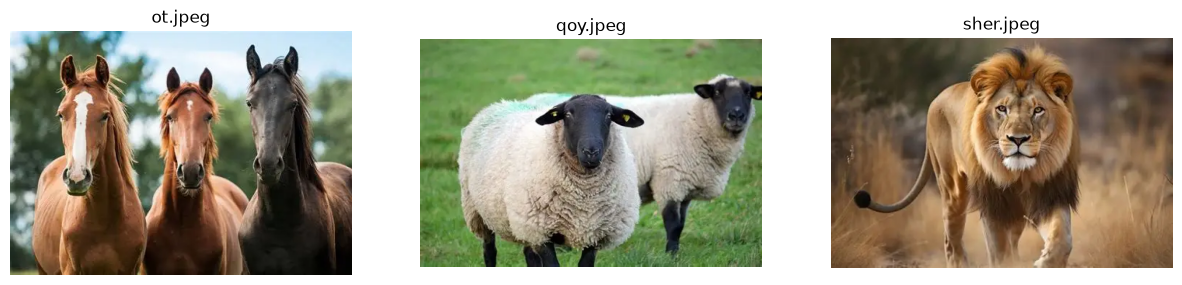

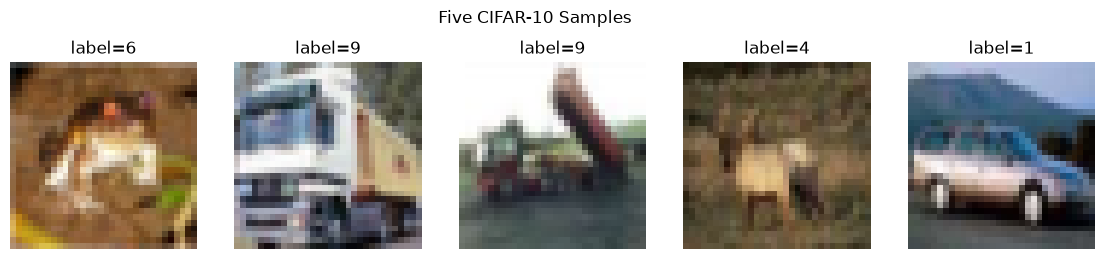

In [7]:
custom_files = sorted(CUSTOM_DIR.glob("*"))
print("Custom image metadata:")
for path in custom_files:
    image = Image.open(path)
    print(f"{path.name}: size={image.size}, mode={image.mode}")

fig, axes = plt.subplots(1, len(custom_files), figsize=(15, 4))
for ax, path in zip(axes, custom_files):
    image = Image.open(path)
    ax.imshow(image)
    ax.set_title(path.name)
    ax.axis("off")
plt.show()

cifar_train = datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=True)
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i in range(5):
    image, label = cifar_train[i]
    axes[i].imshow(image)
    axes[i].set_title(f"label={label}")
    axes[i].axis("off")
plt.suptitle("Five CIFAR-10 Samples")
plt.show()